In [ ]:
!pip install bertopic
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [ ]:
# gunakan embedding model dari IndoBERT
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# import data
df = pd.read_csv('/content/result_2.csv')
df

# filter
df_filtered = df[df['title'] == 'RS Brayat Minulya']
display(df_filtered)

,title,stars,text,bin_pelayanan,bin_fasilitas,predicted_labels_1,labels,prob_layanan,prob_fasilitas
0,RS Brayat Minulya,5,telah dirawat di sini selama beberapa hari di ...,1,1,"['pelayanan', 'fasilitas']",positive,0.996950,0.989263
1,RS Brayat Minulya,5,bersih dan rapi petugas peeawatdokter ditanya ...,1,1,"['pelayanan', 'fasilitas']",positive,0.997084,0.988736
2,RS Brayat Minulya,5,terimakasih atas pelayanan dan perawatan ibu s...,1,0,['pelayanan'],positive,0.997248,0.004785
3,RS Brayat Minulya,5,pelayanan diruang yosef bagus perawat ramah ra...,1,0,['pelayanan'],positive,0.998670,0.012462
4,RS Brayat Minulya,5,tempatnya bagusrapi nyaman sekali ruangan nya ...,1,1,"['pelayanan', 'fasilitas']",positive,0.994812,0.991859
...,...,...,...,...,...,...,...,...,...
1101,RS Brayat Minulya,5,brigitta alicia laura clarina born at rsu bray...,0,0,[],neutral,0.207788,0.006529
1102,RS Brayat Minulya,3,Siipppp,1,1,"['pelayanan', 'fasilitas']",positive,0.992480,0.992916
1103,RS Brayat Minulya,5,bagus dan indah dilihat,1,1,"['pelayanan', 'fasilitas']",positive,0.984027,0.995098
1104,RS Brayat Minulya,4,batas,0,0,[],negative,0.165975,0.441751


In [ ]:
# menghapus stopwords
import re

# daftar
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg', 'dari', 'malah']

# function
def remove_stopwords(text):
    if isinstance(text, str):  # make sure string
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text


df_filtered['text'] = df_filtered['text'].apply(remove_stopwords)

# Kategori

In [ ]:
# insialisasi model untuk dua kategori
layanan_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)
fasilitas_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan probabilitas kategori
def assign_reviews_by_category(data, threshold=0.5):
    layanan_reviews = []
    fasilitas_reviews = []
    layanan_indices = []
    fasilitas_indices = []
    for idx, row in data.iterrows():
        if row['prob_layanan'] >= threshold:
            layanan_reviews.append(row['text'])
            layanan_indices.append(idx)
        if row['prob_fasilitas'] >= threshold:
            fasilitas_reviews.append(row['text'])
            fasilitas_indices.append(idx)
    return layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices

# Memisahkan ulasan (ulasan dengan prob 0.99 masuk ke kedua kategori)
layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices = assign_reviews_by_category(df_filtered, threshold=0.5)

In [ ]:
# Pemodelan topik untuk kategori layanan
if layanan_reviews:
    topics_layanan, probs_layanan = layanan_model.fit_transform(layanan_reviews)
else:
    topics_layanan, probs_layanan = [], []

In [ ]:
# Pemodelan topik untuk kategori fasilitas
if fasilitas_reviews:
    topics_fasilitas, probs_fasilitas = fasilitas_model.fit_transform(fasilitas_reviews)
else:
    topics_fasilitas, probs_fasilitas = [], []

In [ ]:
# layanan_model.update_topics(layanan_reviews, top_n_words=10)  # Batasi ke 10 kata
# fasilitas_model.update_topics(fasilitas_reviews, top_n_words=10)  # Batasi ke 10 kata

## Hasil topic modelling

In [ ]:
# melihat total topic layanan
print(len(layanan_model.get_topics()))

# melihat total topic fasilitas
print(len(fasilitas_model.get_topics()))

4
5


In [ ]:
layanan_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,29,-1_rs_poliklinik_sakit_brayat,"[rs, poliklinik, sakit, brayat, baik, rumah, p...",[3 hari anak dirawat ruang theresia mengguna...
1,0,198,0_pelayanan_bagus_baik_pelayanannya,"[pelayanan, bagus, baik, pelayanannya, ramah, ...","[pelayanan sangat bagus, pelayanan bagus rama..."
2,1,188,1_pasien_jam_dokter_bisa,"[pasien, jam, dokter, bisa, bpjs, perawat, pel...",[pengalaman menganter suami periksa rs brayat...
3,2,632,2_pelayanan_ramah_baik_ruang,"[pelayanan, ramah, baik, ruang, sangat, theres...",[ruang theresia pelayanan baik perawat ramah ...


In [ ]:
fasilitas_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,46,-1_pelayanan_bersih_bagus_rumah,"[pelayanan, bersih, bagus, rumah, bangunan, li...",[rumah sakitnya ramah lingkungan pelayanan ke...
1,0,400,0_pelayanan_ruang_baik_sangat,"[pelayanan, ruang, baik, sangat, ramah, theres...",[ruang teresia kamar 112d pelayanan sangat bai...
2,1,18,1_bagus_tertib_sekali_baguspelayannya,"[bagus, tertib, sekali, baguspelayannya, dilih...","[bagus, bagus, Bagus]"
3,2,12,2_nyaman_tempat_bagus_bersih,"[nyaman, tempat, bagus, bersih, menuju, bus, b...","[bagus ramah nyaman, tempat nyaman, tempat ny..."
4,3,10,3_ruang_theresia_mantul_idaman,"[ruang, theresia, mantul, idaman, 102a, tercin...","[anak dirawat ruang theresia, ruang theresia ..."


## Frekuensi sentimen dari setiap topik

In [ ]:
# === Analisis Topik & Sentimen untuk Layanan ===
df_layanan = df_filtered.iloc[layanan_indices].copy()
df_layanan["topic"] = topics_layanan

df_layanan = df_layanan[df_layanan['topic'] != -1]
topic_sentiment_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'])
emotion_dist_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'], normalize='index')

print("=== Distribusi Sentimen per Topik (Layanan) ===")
print(topic_sentiment_layanan)
print("\n=== Proporsi Sentimen per Topik (Layanan) ===")
print(emotion_dist_layanan)

# === Analisis Topik & Sentimen untuk Fasilitas ===
df_fasilitas = df_filtered.iloc[fasilitas_indices].copy()
df_fasilitas["topic"] = topics_fasilitas

df_fasilitas = df_fasilitas[df_fasilitas['topic'] != -1]
topic_sentiment_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'])
emotion_dist_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'], normalize='index')

print("\n=== Distribusi Sentimen per Topik (Fasilitas) ===")
print(topic_sentiment_fasilitas)
print("\n=== Proporsi Sentimen per Topik (Fasilitas) ===")
print(emotion_dist_fasilitas)


=== Distribusi Sentimen per Topik (Layanan) ===
labels  negative  neutral  positive
topic                              
0             15        5       178
1            134       17        37
2             11       25       596

=== Proporsi Sentimen per Topik (Layanan) ===
labels  negative   neutral  positive
topic                               
0       0.075758  0.025253  0.898990
1       0.712766  0.090426  0.196809
2       0.017405  0.039557  0.943038

=== Distribusi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0             31       19       350
1              1        0        17
2              0        0        12
3              0        4         6

=== Proporsi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0       0.077500   0.0475  0.875000
1       0.055556   0.0000  0.944444
2       0.000000   0.0000  1.000000
3       0.000000   0.4000  0.600000


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

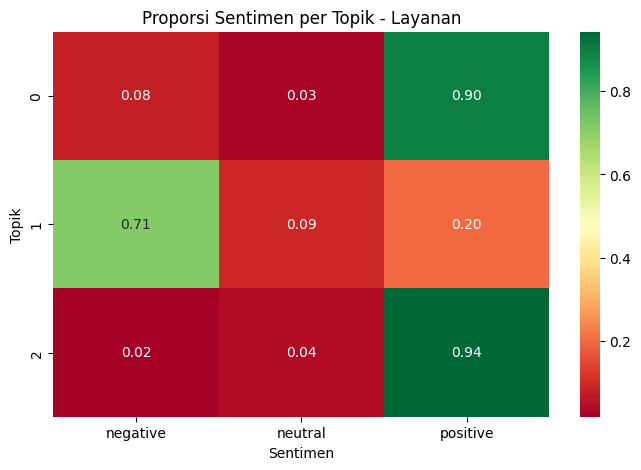

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_layanan, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Layanan")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

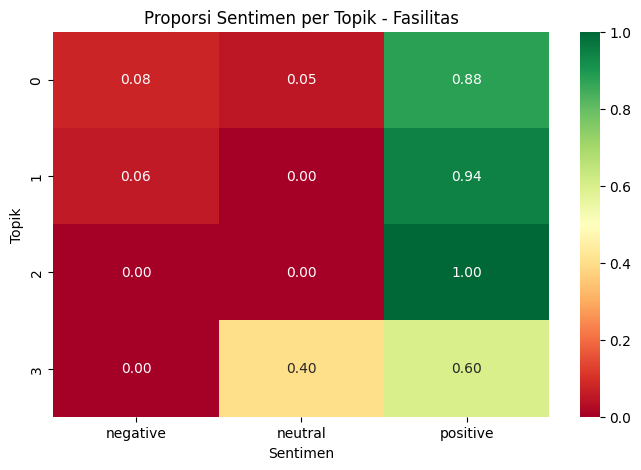

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_fasilitas, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Fasilitas")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

In [ ]:
# Fungsi untuk menampilkan kata kunci tiap topik
def tampilkan_topik(model, kategori):
    topics = model.get_topics()
    print(f"=== Topik untuk kategori {kategori} ===")
    for topic_id, topic_info in topics.items():
        print(f"Topic {topic_id}:")
        print(f"Representasi: {topic_info}")
        print("-" * 50)
    print("\n")

# Panggil untuk layanan dan fasilitas
tampilkan_topik(layanan_model, "Layanan")
tampilkan_topik(fasilitas_model, "Fasilitas")

=== Topik untuk kategori Layanan ===
Topic -1:
Representasi: [('rs', np.float64(0.06971016308417897)), ('poliklinik', np.float64(0.05917967646862564)), ('sakit', np.float64(0.054872441992383454)), ('brayat', np.float64(0.05406785699115668)), ('baik', np.float64(0.053662100080367627)), ('rumah', np.float64(0.050836005211536944)), ('pelayanan', np.float64(0.04603210861345009)), ('jl', np.float64(0.04308148434608236)), ('sini', np.float64(0.04129340747721422)), ('putri', np.float64(0.04010243465490019))]
--------------------------------------------------
Topic 0:
Representasi: [('pelayanan', np.float64(0.2613818604628402)), ('bagus', np.float64(0.22820175778868354)), ('baik', np.float64(0.1555274629026627)), ('pelayanannya', np.float64(0.1469932795471346)), ('ramah', np.float64(0.14680464003094873)), ('sangat', np.float64(0.13058406142349568)), ('cepat', np.float64(0.11254642053315567)), ('memuaskan', np.float64(0.08486382777999969)), ('kasih', np.float64(0.04881349776752868)), ('nyaman',

# Sentimen

In [ ]:
# insialisasi model untuk dua sentimen
positive_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=8)
negative_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=6)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan sentimen
def assign_reviews_by_sentiment(data):
    positif_reviews = data[data['labels'] == 'positive']['text'].tolist()
    negatif_reviews = data[data['labels'] == 'negative']['text'].tolist()
    positif_indices = data[data['labels'] == 'positive'].index.tolist()
    negatif_indices = data[data['labels'] == 'negative'].index.tolist()
    return positif_reviews, negatif_reviews, positif_indices, negatif_indices

In [ ]:
# Memisahkan ulasan berdasarkan sentimen
positif_reviews, negatif_reviews, positif_indices, negatif_indices = assign_reviews_by_sentiment(df_filtered)

In [ ]:
# Pemodelan topik untuk sentimen positif
if positif_reviews:
    topics_positif, probs_positif = positive_model.fit_transform(positif_reviews)
else:
    topics_positif, probs_positif = [], []

In [ ]:
# Pemodelan topik untuk sentimen negatif
if negatif_reviews:
    topics_negatif, probs_negatif = negative_model.fit_transform(negatif_reviews)
else:
    topics_negatif, probs_negatif = [], []

## Hasil Topic Modelling

In [ ]:
# melihat total topic positive
print(len(positive_model.get_topics()))

# melihat total topic negative
print(len(negative_model.get_topics()))

3
4


In [ ]:
positive_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_baikjadwal_cepatkebersihan_transit_oprasi,"[baikjadwal, cepatkebersihan, transit, oprasi,...",[pelayanannya memuaskan selama opname ruang ...
1,0,203,0_pelayanan_bagus_ramah_baik,"[pelayanan, bagus, ramah, baik, sangat, pelaya...","[pelayanan sangat bagus, pelayanan bagus rama..."
2,1,660,1_pelayanan_ramah_baik_sangat,"[pelayanan, ramah, baik, sangat, ruang, brayat...",[terimakasih semua perawat rs brayat minulya p...


In [ ]:
negative_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,70,-1_dokter_pelayanan_jam_pasien,"[dokter, pelayanan, jam, pasien, banget, lebih...",[terlalu banyak waktu terbuang mengantri pen...
1,0,15,0_kurang_bagus_pelayanan_lama,"[kurang, bagus, pelayanan, lama, pelayanannya,...",[kelas 2 kotor sih akhirnya pindah vip pelay...
2,1,18,1_gk_rs_mau_tdk,"[gk, rs, mau, tdk, udh, pasien, mlh, klu, bpk,...",[pelayanan buruk rs terparah mungkin bisa jadi...
3,2,71,2_pasien_perawat_pelayanan_jam,"[pasien, perawat, pelayanan, jam, sangat, dokt...",[rumah sakit cagar budaya masih aktif solo ...


In [ ]:
# Panggil untuk layanan dan fasilitas
tampilkan_topik(positive_model, "Positif")
tampilkan_topik(negative_model, "Negatif")

=== Topik untuk kategori Positif ===
Topic -1:
Representasi: [('baikjadwal', np.float64(0.6937553078025998)), ('cepatkebersihan', np.float64(0.6360132374327196)), ('transit', np.float64(0.531717223432018)), ('oprasi', np.float64(0.531717223432018)), ('opname', np.float64(0.4740960135111228)), ('pun', np.float64(0.44449381616795036)), ('selama', np.float64(0.3913670906223825)), ('memuaskan', np.float64(0.30132368524651176)), ('pelayanannya', np.float64(0.29257980441693726)), ('ruang', np.float64(0.22584074481600486))]
--------------------------------------------------
Topic 0:
Representasi: [('pelayanan', np.float64(0.25176787528069045)), ('bagus', np.float64(0.21619472904121242)), ('ramah', np.float64(0.14413010989864064)), ('baik', np.float64(0.14207388538654622)), ('sangat', np.float64(0.1385914632041719)), ('pelayanannya', np.float64(0.13487472376483062)), ('cepat', np.float64(0.10474839238280778)), ('memuaskan', np.float64(0.08247515034358306)), ('bersih', np.float64(0.072611063197